In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from google.colab import files

uploaded = files.upload()

# load excel sheet — data starts row 4, columns B through H
df = pd.read_excel(
    list(uploaded.keys())[0],
    sheet_name='Sheet1',
    header=3,
    usecols='B:H'
)

# rename columns
df.columns = ['timestamp', 'hours', 'brix_raw', 'gravity_manual', 'pH', 'EC', 'temp']

# hours elapsed is primary x axis, timestamp irrelevant
df = df.drop(columns=['timestamp'])

# last row with gravity value is hydrometer reading
hydro_idx = df['gravity_manual'].last_valid_index()
df['is_hydrometer'] = False
df.loc[hydro_idx, 'is_hydrometer'] = True

# pull hydrometer reading, apply temperature correction
# hydrometer calibrated at 60F, mead at room temp (~71F), adjustment
hydrometer_raw = df.loc[hydro_idx, 'gravity_manual']
hydrometer_temp_c = df.loc[hydro_idx, 'temp']
hydrometer_temp_f = hydrometer_temp_c * 9/5 + 32
cal_temp = 60.0  # calibration temp in F

# standard correction factor is 0.00013 SG per F
hydrometer_corrected = hydrometer_raw + 0.00013 * (hydrometer_temp_f - cal_temp)

print(f"Hydrometer raw reading:            {hydrometer_raw:.4f}")
print(f"Measurement temp:                  {hydrometer_temp_c:.1f}°C / {hydrometer_temp_f:.1f}°F")
print(f"Temperature corrected gravity:     {hydrometer_corrected:.4f}")
# matches manual calculation

# drop gravity_manual column — recalculate corrected gravity for refractometer rows
# will use Sean Terrill formula in cell 2
df = df.drop(columns=['gravity_manual'])

# drop rows without hours elapsed
df = df[df['hours'].notna()]
df = df.reset_index(drop=True)
print(f"rows loaded: {len(df)}")  # sanity check

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nLast 3 rows:")
print(df.tail(3))

Saving mead.xlsx to mead.xlsx
Hydrometer raw reading:            0.9960
Measurement temp:                  21.8°C / 71.2°F
Temperature corrected gravity:     0.9975

Dataset shape: (31, 6)

First 3 rows:
   hours  brix_raw   pH    EC  temp  is_hydrometer
0   0.00      24.0  3.8  1.08  24.6          False
1  14.25      24.0  3.7  1.09  22.0          False
2  26.00      23.5  3.6  1.35  21.5          False

Last 3 rows:
     hours  brix_raw   pH    EC  temp  is_hydrometer
28  337.00       9.0  4.0  1.35  21.7          False
29  348.75       9.0  4.0  1.33  21.8          False
30  363.50       NaN  4.0  1.33  21.8           True


In [2]:
# Cell 2 — Sean Terrill correction and ABV calculation

OG_brix = 24.0
OG_gravity = 1.1023  # starting gravity calculated from 24 brix pre-ferm
WCF = 1.04  # wort correction factor for refractometer

# Sean Terrill formula — corrects refractometer readings during fermentation
# alcohol presence intensifies refractometer signal
# both brix readings get divided by the wort correction factor
def sean_terrill(current_brix, og_brix):
    ri = current_brix / WCF
    og = og_brix / WCF
    sg = (1.0000
          - 0.0044993 * og
          + 0.011774 * ri
          + 0.00027581 * og**2
          - 0.0012717 * ri**2
          - 0.0000072800 * og**3
          + 0.000063293 * ri**3)
    return sg

# brix to SG conversion — only accurate before fermentation starts since no alcohol present
def brix_to_sg_simple(brix):
    sg = 1 + (brix / (258.6 - (brix / 0.879) * 0.88))
    return sg

# figure out which correction to apply for each row
# three cases: T=0 (no alcohol yet), hydrometer row, everything else
gravity_values = []
for idx, row in df.iterrows():
    if row['is_hydrometer']:
        # hydrometer row gets the temperature corrected value from cell 1
        gravity_values.append(hydrometer_corrected)
    elif row['hours'] == 0:
        # pre-ferm — no alcohol so simple brix conversion
        gravity_values.append(brix_to_sg_simple(row['brix_raw']))
    else:
        # active fermentation — need Sean Terrill to correct
        gravity_values.append(sean_terrill(row['brix_raw'], OG_brix))

df['gravity'] = gravity_values

# calculate ABV at each timepoint using standard homebrew formula
# (OG - FG) * 131.25 gives percent ABV
df['ABV'] = (OG_gravity - df['gravity']) * 131.25


# clip negative ABV values — in early readings where Sean Terrill overcorrects before enough alcohol present
df['ABV'] = df['ABV'].clip(lower=0)

print(df[['hours', 'brix_raw', 'gravity', 'ABV', 'is_hydrometer']].to_string())

# compare Sean Terrill estimate to hydrometer grounding value at end of fermentation
st_final = df.loc[~df['is_hydrometer'], 'gravity'].iloc[-1]
error = abs(st_final - hydrometer_corrected)

print(f"\nSean Terrill final gravity estimate: {st_final:.4f}")
print(f"Hydrometer corrected final gravity:  {hydrometer_corrected:.4f}")

print(f"Correction formula error:            {error:.4f} SG units")
print(f"\nFinal ABV (hydrometer based):        {(OG_gravity - hydrometer_corrected) * 131.25:.2f}%")

     hours  brix_raw   gravity        ABV  is_hydrometer
0     0.00      24.0  1.102314   0.000000          False
1    14.25      24.0  1.325893   0.000000          False
2    26.00      23.5  1.300548   0.000000          False
3    36.50      21.0  1.193909   0.000000          False
4    47.75      18.5  1.116885   0.000000          False
5    61.00      16.0  1.064199   5.000805          False
6    72.50      13.0  1.025675  10.057080          False
7    84.25      11.5  1.013858  11.607971          False
8    96.25      11.0  1.010741  12.017083          False
9   109.25      11.0  1.010741  12.017083          False
10  120.75      10.5  1.007965  12.381500          False
11  132.00      10.5  1.007965  12.381500          False
12  142.50      10.5  1.007965  12.381500          False
13  153.50      10.0  1.005487  12.706761          False
14  169.00      10.0  1.005487  12.706761          False
15  177.75      10.0  1.005487  12.706761          False
16  192.50       9.5  1.003265 

In [3]:
# Cell 3 — Data Cleaning and Outlier Filtering

# make copy before doing anything so i keep raw version
df_raw = df.copy()

# pull out refractometer rows for outlier analysis, hydrometer row would flag as an outlier since brix=blank
df_refrac = df[~df['is_hydrometer']].copy()

# IQR outlier detection — flags anything more than 1.5x interquartile range from Q1 or Q3 as potential outlier
def flag_outliers_IQR(series, threshold=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold * IQR
    upper = Q3 + threshold * IQR
    # return boolean series — True where value outside the bounds
    outlier_mask = (series < lower) | (series > upper)
    return outlier_mask

# run outlier detection on each variable separately
outlier_cols = ['brix_raw', 'gravity', 'pH', 'EC', 'temp']
outlier_flags = pd.DataFrame(index=df_refrac.index)

for col in outlier_cols:
    outlier_flags[col] = flag_outliers_IQR(df_refrac[col])

print("Outliers detected per column:")

print(outlier_flags.sum())

# find rows where at least one variable flagged
any_outlier = outlier_flags.any(axis=1)
flagged_rows = df_refrac[any_outlier]

print("\nOutlier rows:")
print(flagged_rows.to_string())

Outliers detected per column:
brix_raw    6
gravity     6
pH          0
EC          0
temp        2
dtype: int64

Outlier rows:
     hours  brix_raw   pH    EC  temp  is_hydrometer   gravity        ABV
0     0.00      24.0  3.8  1.08  24.6          False  1.102314   0.000000
1    14.25      24.0  3.7  1.09  22.0          False  1.325893   0.000000
2    26.00      23.5  3.6  1.35  21.5          False  1.300548   0.000000
3    36.50      21.0  3.4  0.99  22.4          False  1.193909   0.000000
4    47.75      18.5  3.2  1.03  24.4          False  1.116885   0.000000
5    61.00      16.0  3.3  0.97  23.5          False  1.064199   5.000805
14  169.00      10.0  3.7  1.32  26.5          False  1.005487  12.706761


In [4]:
# Cell 3 continued — how to handle flagged rows

# rows 0-5 got flagged but these arent real outliers, active fermentation phase where brix and gravity are high
# Sean Terrill formula is less accurate this early on (< 60% attenuation)
# keep these rows but will mark them differently on plots

# row 14 is real outlier — temp spiked to 26.5C and EC jumped to 1.32 mS
# this lines up with days 6-8 when the living room thermostat stopped working
# can smooth EC and temp with a rolling median

window = 3  # 3-point window = smoothing over 36 hours

# calculate smoothed columns
EC_smoothed = []
temp_smoothed = []

for i in range(len(df)):
    # grab window around each point
    start = max(0, i - 1)
    end = min(len(df), i + 2)
    EC_smoothed.append(df['EC'].iloc[start:end].median())
    temp_smoothed.append(df['temp'].iloc[start:end].median())

df['EC_smooth'] = EC_smoothed
df['temp_smooth'] = temp_smoothed

# flag row 14
df['outlier_flag'] = False
df.loc[14, 'outlier_flag'] = True

print("Smoothing applied to EC and temp")
print(f"\nRow 14 raw vs smoothed:")

print(f"  EC:   {df.loc[14, 'EC']:.3f} mS  →  {df.loc[14, 'EC_smooth']:.3f} mS (smoothed)")
print(f"  Temp: {df.loc[14, 'temp']:.1f}°C  →  {df.loc[14, 'temp_smooth']:.1f}°C (smoothed)")
print(f"\nFull dataset with smoothed columns:")
print(df[['hours', 'EC', 'EC_smooth', 'temp', 'temp_smooth', 'outlier_flag']].to_string())

Smoothing applied to EC and temp

Row 14 raw vs smoothed:
  EC:   1.320 mS  →  1.220 mS (smoothed)
  Temp: 26.5°C  →  22.0°C (smoothed)

Full dataset with smoothed columns:
     hours    EC  EC_smooth  temp  temp_smooth  outlier_flag
0     0.00  1.08      1.085  24.6         23.3         False
1    14.25  1.09      1.090  22.0         22.0         False
2    26.00  1.35      1.090  21.5         22.0         False
3    36.50  0.99      1.030  22.4         22.4         False
4    47.75  1.03      0.990  24.4         23.5         False
5    61.00  0.97      1.030  23.5         23.5         False
6    72.50  1.07      1.070  22.5         22.9         False
7    84.25  1.09      1.070  22.9         22.5         False
8    96.25  0.94      0.940  22.2         22.8         False
9   109.25  0.93      0.940  22.8         22.3         False
10  120.75  0.98      0.980  22.3         22.8         False
11  132.00  1.06      1.060  22.9         22.9         False
12  142.50  1.17      1.170  23.4 

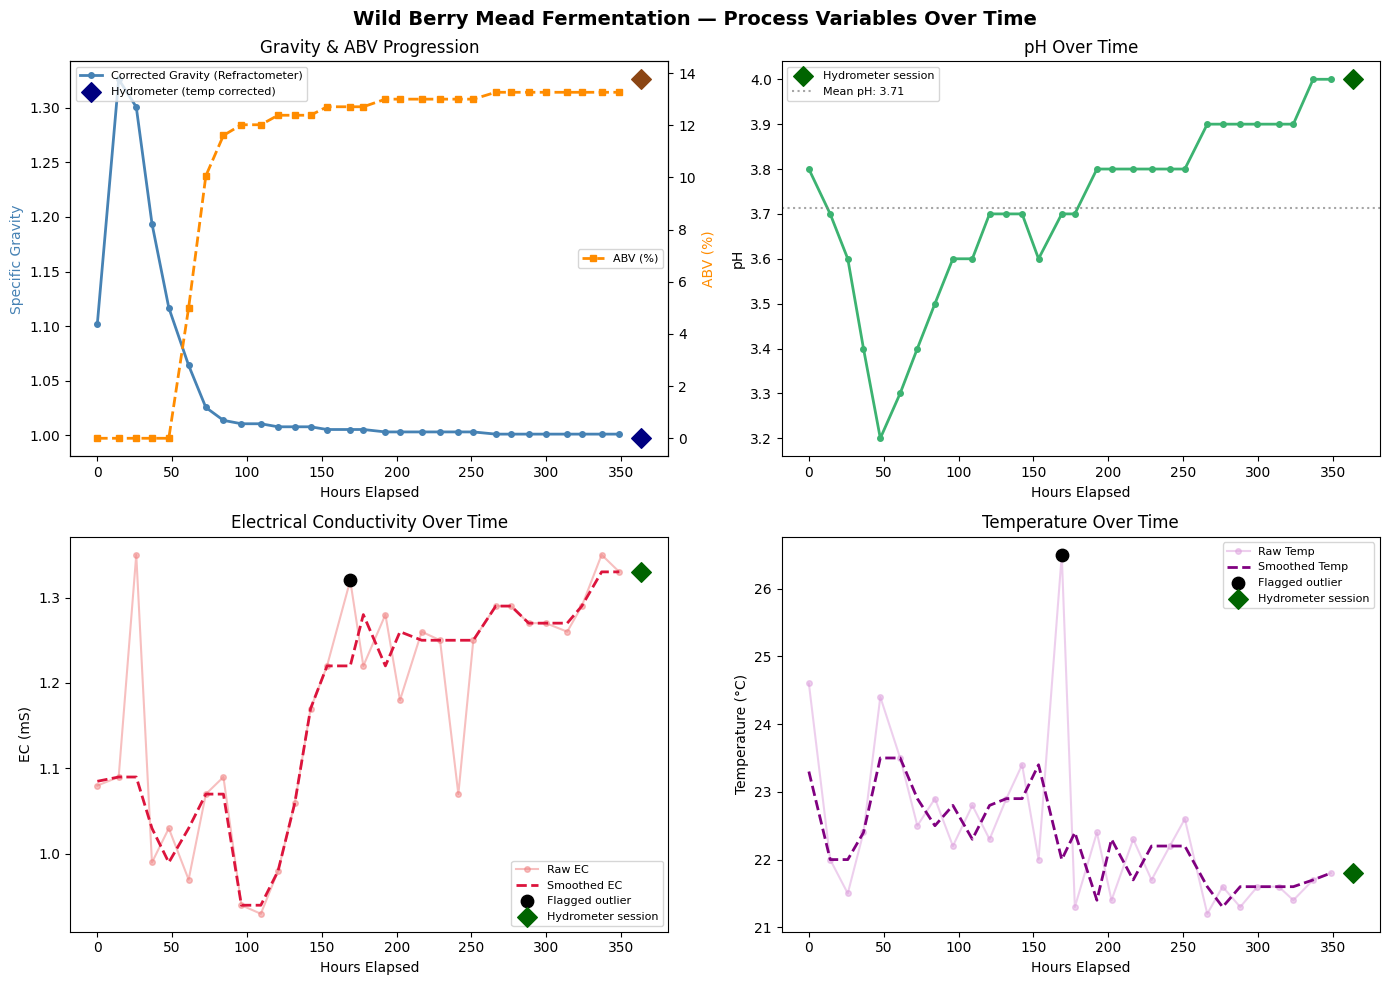

Plot saved as fermentation_overview.png


In [5]:
# Cell 4 — Visualization of fermentation variables

# split refractometer and hydrometer dataframes, plotting separately
df_refrac = df[~df['is_hydrometer']].copy()
df_hydro = df[df['is_hydrometer']].copy()

# calculate mean pH ahead of time for the reference line on plot 2
mean_pH = df_refrac['pH'].mean()

# pull outlier row out
outlier_row = df[df['outlier_flag'] == True]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Wild Berry Mead Fermentation — Process Variables Over Time',
             fontsize=14, fontweight='bold')

# Plot 1: Gravity and ABV, two y axes
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

ax1.plot(df_refrac['hours'], df_refrac['gravity'], color='steelblue',
         linewidth=2, marker='o', markersize=4, label='Corrected Gravity (Refractometer)')
ax1.scatter(df_hydro['hours'], df_hydro['gravity'], color='navy',
            zorder=6, s=100, marker='D', label='Hydrometer (temp corrected)')
ax1_twin.plot(df_refrac['hours'], df_refrac['ABV'], color='darkorange',
              linewidth=2, marker='s', markersize=4, linestyle='--', label='ABV (%)')
ax1_twin.scatter(df_hydro['hours'], df_hydro['ABV'], color='saddlebrown',
                 zorder=6, s=100, marker='D')

ax1.set_xlabel('Hours Elapsed')
ax1.set_ylabel('Specific Gravity', color='steelblue')
ax1_twin.set_ylabel('ABV (%)', color='darkorange')
ax1.set_title('Gravity & ABV Progression')
ax1.legend(loc='upper left', fontsize=8)
ax1_twin.legend(loc='center right', fontsize=8)

# Plot 2: pH
# pH dropped sharply during active fermentation then recovered
ax2 = axes[0, 1]
ax2.plot(df_refrac['hours'], df_refrac['pH'], color='mediumseagreen',
         linewidth=2, marker='o', markersize=4)
ax2.scatter(df_hydro['hours'], df_hydro['pH'], color='darkgreen',
            zorder=6, s=100, marker='D', label='Hydrometer session')
ax2.axhline(y=mean_pH, color='gray', linestyle=':',
            alpha=0.7, label=f'Mean pH: {mean_pH:.2f}')
ax2.set_xlabel('Hours Elapsed')
ax2.set_ylabel('pH')

ax2.set_title('pH Over Time')
ax2.legend(fontsize=8)

# Plot 3: EC raw vs smoothed
# smoothed line clarifies trend
# flagged outlier at hour 169 is the broken thermostat period

ax3 = axes[1, 0]
ax3.plot(df_refrac['hours'], df_refrac['EC'], color='lightcoral',
         linewidth=1.5, marker='o', markersize=4, alpha=0.5, label='Raw EC')
ax3.plot(df_refrac['hours'], df_refrac['EC_smooth'], color='crimson',
         linewidth=2, linestyle='--', label='Smoothed EC')
ax3.scatter(outlier_row['hours'], outlier_row['EC'],
            color='black', zorder=5, s=80, label='Flagged outlier')
ax3.scatter(df_hydro['hours'], df_hydro['EC'], color='darkgreen',
            zorder=6, s=100, marker='D', label='Hydrometer session')
ax3.set_xlabel('Hours Elapsed')
ax3.set_ylabel('EC (mS)')
ax3.set_title('Electrical Conductivity Over Time')
ax3.legend(fontsize=8)

# Plot 4: Temperature raw vs smoothed
# same thermostat spike — smoothing it helps
ax4 = axes[1, 1]
ax4.plot(df_refrac['hours'], df_refrac['temp'], color='plum',
         linewidth=1.5, marker='o', markersize=4, alpha=0.5, label='Raw Temp')
ax4.plot(df_refrac['hours'], df_refrac['temp_smooth'], color='purple',
         linewidth=2, linestyle='--', label='Smoothed Temp')
ax4.scatter(outlier_row['hours'], outlier_row['temp'],
            color='black', zorder=5, s=80, label='Flagged outlier')
ax4.scatter(df_hydro['hours'], df_hydro['temp'], color='darkgreen',
            zorder=6, s=100, marker='D', label='Hydrometer session')
ax4.set_xlabel('Hours Elapsed')
ax4.set_ylabel('Temperature (°C)')
ax4.set_title('Temperature Over Time')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fermentation_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as fermentation_overview.png")

Logistic fit results:
  Final gravity asymptote (L):   1.00449
  Rate constant (k):             0.29128
  Inflection point:              70.8 hours (absolute time)
  Upper gravity (anchored):      1.06420
  R²:                            0.9283


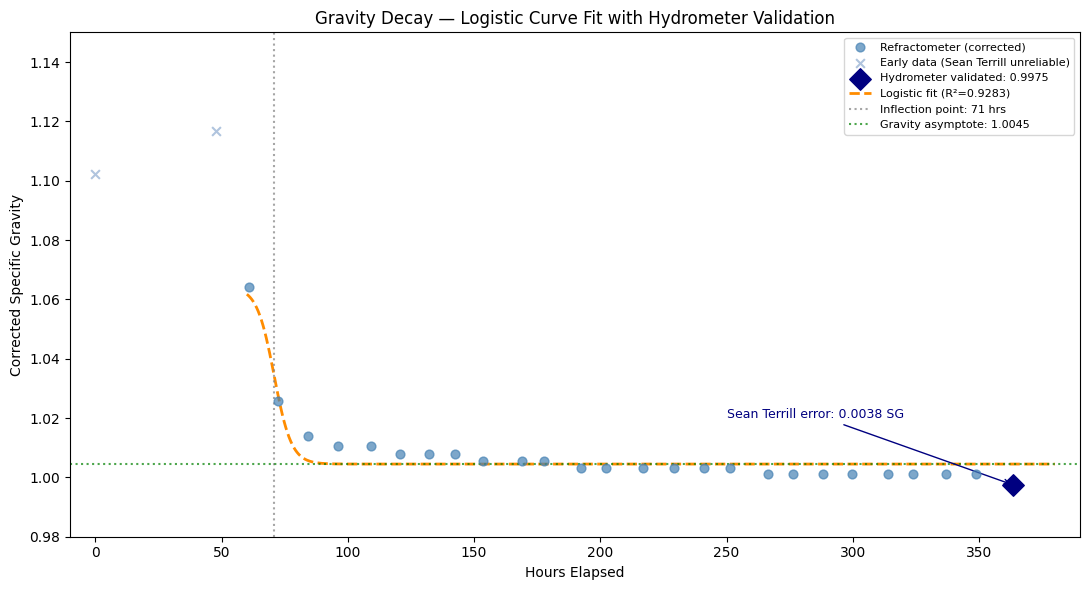


Fitted final ABV estimate (logistic): 12.84%
Hydrometer validated ABV:             13.76%
ABV difference (model vs hydrometer): 0.92%


In [6]:
# Cell 5 — Logistic curve fit to gravity data
# use only data from hour 60+ — Sean Terrill correction unreliable, not enough alcohol present

# filter to more reliable range and shift time axis start to 0
# fitting without shifting gives an inflection point of -95 hours, so this remedies that
df_fit = df[(df['hours'] >= 60) & (~df['is_hydrometer'])].copy()
df_fit['hours_shifted'] = df_fit['hours'] - 60

# make upper bound of the logistic to the actual first reliable gravity reading, the optimizer only has to find L, k, and t0
upper = df_fit['gravity'].iloc[0]

# logistic decay function
# L = final gravity floor (asymptote)
# k = rate constant
# t0 = inflection point in shifted hours
def logistic_decay(t, L, k, t0):
    return L + (upper - L) / (1 + np.exp(k * (t - t0)))

# initial guesses — L near final gravity, k small positive, t0 somewhere early
p0 = [1.001, 0.08, 15]

popt, pcov = curve_fit(
    logistic_decay,
    df_fit['hours_shifted'],
    df_fit['gravity'],
    p0=p0,
    maxfev=10000
)

# unpack parameters
L = popt[0]
k = popt[1]
t0 = popt[2]

# calculate R-squared
gravity_pred = logistic_decay(df_fit['hours_shifted'], *popt)
ss_res = np.sum((df_fit['gravity'] - gravity_pred)**2)
ss_tot = np.sum((df_fit['gravity'] - df_fit['gravity'].mean())**2)
r_squared = 1 - (ss_res / ss_tot)

print("Logistic fit results:")
print(f"  Final gravity asymptote (L):   {L:.5f}")
print(f"  Rate constant (k):             {k:.5f}")
print(f"  Inflection point:              {t0 + 60:.1f} hours (absolute time)")
print(f"  Upper gravity (anchored):      {upper:.5f}")
print(f"  R²:                            {r_squared:.4f}")

# generate smooth curve
# convert shifted hours back to normal hours for x axis
t_smooth = np.linspace(0, 320, 500)
gravity_smooth = logistic_decay(t_smooth, *popt)
hours_smooth = t_smooth + 60

# split data
df_refrac = df[~df['is_hydrometer']].copy()
df_hydro = df[df['is_hydrometer']].copy()

# early data points plotted separately since Sean Terrill is unreliable there
df_early = df_refrac[df_refrac['hours'] < 60]
df_reliable = df_refrac[df_refrac['hours'] >= 60]

# pull S.T. final estimate and calculate error vs hydrometer
st_final = df_refrac['gravity'].iloc[-1]
st_error = abs(st_final - hydrometer_corrected)

# plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(df_reliable['hours'], df_reliable['gravity'], color='steelblue',
           zorder=5, s=40, label='Refractometer (corrected)', alpha=0.7)
ax.scatter(df_early['hours'], df_early['gravity'], color='lightsteelblue',
           zorder=5, s=40, marker='x', label='Early data (Sean Terrill unreliable)')
ax.scatter(df_hydro['hours'], df_hydro['gravity'], color='navy',
           zorder=6, s=120, marker='D',
           label=f'Hydrometer validated: {hydrometer_corrected:.4f}')
ax.plot(hours_smooth, gravity_smooth, color='darkorange',
        linewidth=2, linestyle='--', label=f'Logistic fit (R²={r_squared:.4f})')
ax.axvline(x=t0 + 60, color='gray', linestyle=':', alpha=0.7,
           label=f'Inflection point: {t0 + 60:.0f} hrs')
ax.axhline(y=L, color='green', linestyle=':', alpha=0.7,
           label=f'Gravity asymptote: {L:.4f}')

ax.annotate(f'Sean Terrill error: {st_error:.4f} SG',
            xy=(df_hydro['hours'].values[0], hydrometer_corrected),
            xytext=(250, 1.02),
            arrowprops=dict(arrowstyle='->', color='navy'),
            fontsize=9, color='navy')

ax.set_xlabel('Hours Elapsed')
ax.set_ylabel('Corrected Specific Gravity')
ax.set_title('Gravity Decay — Logistic Curve Fit with Hydrometer Validation')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(-10, 390)
ax.set_ylim(0.98, 1.15)

plt.tight_layout()
plt.savefig('logistic_fit.png', dpi=150, bbox_inches='tight')
plt.show()

# compare logistic model ABV estimate to hydrometer ABV
logistic_abv = (OG_gravity - L) * 131.25
hydro_abv = (OG_gravity - hydrometer_corrected) * 131.25
abv_diff = abs(logistic_abv - hydro_abv)

print(f"\nFitted final ABV estimate (logistic): {logistic_abv:.2f}%")
print(f"Hydrometer validated ABV:             {hydro_abv:.2f}%")
print(f"ABV difference (model vs hydrometer): {abv_diff:.2f}%")

In [7]:
# Cell 6 — Fermentation Rate Analysis (dGravity/dt)
# numerically differentiating gravity over time to identify fermentation phase

# working with refractometer data only — hydrometer row would mess up derivative
df_rate = df[~df['is_hydrometer']].copy().reset_index(drop=True)

# calculate dG/dt at each timepoint using numpy gradient, uneven time spacings in data
df_rate['dG_dt'] = np.gradient(df_rate['gravity'], df_rate['hours'])

# gravity is dropping so dG/dt is negative during active fermentation
# flip sign to represent fermentation rate
df_rate['ferm_rate'] = df_rate['dG_dt'] * -1

# phase boundaries based on look of rate curve
# lag phase: hours 0-60 — yeast establishing, rate=low
# exponential phase: hours 60-100 — peak activity, steepest gravity drop
# stationary phase: hours 100+ — rate approaching zero, sugars mostly consumed
lag_end = 60
exp_end = 100

print("Fermentation rate at each timepoint:")
print(df_rate[['hours', 'gravity', 'ferm_rate']].to_string())

# find peak rate and when it occurred
peak_rate = df_rate['ferm_rate'].max()
peak_hour = df_rate.loc[df_rate['ferm_rate'].idxmax(), 'hours']
print(f"\nPeak fermentation rate: {peak_rate:.6f} SG/hr")
print(f"At hour: {peak_hour:.1f}")

# calculate mean rates for each phase
exp_rows = df_rate[(df_rate['hours'] >= lag_end) & (df_rate['hours'] <= exp_end)]
stat_rows = df_rate[df_rate['hours'] > exp_end]

exp_mean = exp_rows['ferm_rate'].mean()
stat_mean = stat_rows['ferm_rate'].mean()

print(f"\nMean rate during exponential phase: {exp_mean:.6f} SG/hr")
print(f"Mean rate during stationary phase:  {stat_mean:.6f} SG/hr")

Fermentation rate at each timepoint:
     hours   gravity     ferm_rate
0     0.00  1.102314 -1.568978e-02
1    14.25  1.325893 -5.908338e-03
2    26.00  1.300548  6.381225e-03
3    36.50  1.193909  8.558381e-03
4    47.75  1.116885  5.528632e-03
5    61.00  1.064199  3.640970e-03
6    72.50  1.025675  2.190382e-03
7    84.25  1.013858  6.366242e-04
8    96.25  1.010741  1.350718e-04
9   109.25  1.010741  1.281088e-04
10  120.75  1.007965  1.193913e-04
11  132.00  1.007965 -0.000000e+00
12  142.50  1.007965  1.100249e-04
13  153.50  1.005487  1.317729e-04
14  169.00  1.005487 -0.000000e+00
15  177.75  1.005487  5.609217e-05
16  192.50  1.003265  5.995157e-05
17  202.25  1.003265  3.469447e-18
18  216.75  1.003265 -6.938894e-18
19  229.00  1.003265 -0.000000e+00
20  241.25  1.003265  6.938894e-18
21  251.25  1.003265  5.354992e-05
22  266.25  1.001256  5.434521e-05
23  276.50  1.001256  6.938894e-18
24  288.25  1.001256 -0.000000e+00
25  299.75  1.001256 -0.000000e+00
26  314.00  1.0012

In [8]:
# Cell 6 continued — filter to more reliable data range and recalculate rate

# data from hours 0-60 has innaccurate rate values because S.T. overcorrects there, derivative comes out wrong

df_rate_reliable = df_rate[df_rate['hours'] >= 60].copy().reset_index(drop=True)

print(f"working with {len(df_rate_reliable)} data points from hour 60 onward")

# recalculate gradient on the reliable subset
df_rate_reliable['dG_dt'] = np.gradient(
    df_rate_reliable['gravity'],
    df_rate_reliable['hours']
)
df_rate_reliable['ferm_rate'] = df_rate_reliable['dG_dt'] * -1

# late stage fermentation produces values like 6.9e-18 which are effectively zero, clip anything negative to zero to clean up
cleaned_rates = []
for rate in df_rate_reliable['ferm_rate']:
    if rate < 0:
        cleaned_rates.append(0)
    else:
        cleaned_rates.append(rate)
df_rate_reliable['ferm_rate'] = cleaned_rates

exp_end = 100

print("Fermentation rate (reliable range only):")
print(df_rate_reliable[['hours', 'gravity', 'ferm_rate']].to_string())

# peak rate in reliable range
peak_rate_r = df_rate_reliable['ferm_rate'].max()
peak_hour_r = df_rate_reliable.loc[df_rate_reliable['ferm_rate'].idxmax(), 'hours']
print(f"\nPeak fermentation rate: {peak_rate_r:.6f} SG/hr")
print(f"At hour: {peak_hour_r:.1f}")

# mean rates by phase
exp_rows_r = df_rate_reliable[df_rate_reliable['hours'] <= exp_end]
stat_rows_r = df_rate_reliable[df_rate_reliable['hours'] > exp_end]

exp_mean_r = exp_rows_r['ferm_rate'].mean()
stat_mean_r = stat_rows_r['ferm_rate'].mean()

print(f"\nMean rate — exponential phase (hr 60-100): {exp_mean_r:.6f} SG/hr")
print(f"Mean rate — stationary phase (hr 100+):    {stat_mean_r:.6f} SG/hr")

# rate ratio — how much faster was exponential phase vs stationary
# use max() to avoid dividing by zero if stat_mean rounds to 0
rate_ratio = exp_mean_r / max(stat_mean_r, 1e-10)
print(f"\nRate ratio (exponential/stationary): {rate_ratio:.1f}x")

Fermentation rate (reliable range only):
     hours   gravity     ferm_rate
0    61.00  1.064199  3.349913e-03
1    72.50  1.025675  2.190382e-03
2    84.25  1.013858  6.366242e-04
3    96.25  1.010741  1.350718e-04
4   109.25  1.010741  1.281088e-04
5   120.75  1.007965  1.193913e-04
6   132.00  1.007965 -0.000000e+00
7   142.50  1.007965  1.100249e-04
8   153.50  1.005487  1.317729e-04
9   169.00  1.005487 -0.000000e+00
10  177.75  1.005487  5.609217e-05
11  192.50  1.003265  5.995157e-05
12  202.25  1.003265  3.469447e-18
13  216.75  1.003265  0.000000e+00
14  229.00  1.003265 -0.000000e+00
15  241.25  1.003265  6.938894e-18
16  251.25  1.003265  5.354992e-05
17  266.25  1.001256  5.434521e-05
18  276.50  1.001256  6.938894e-18
19  288.25  1.001256 -0.000000e+00
20  299.75  1.001256 -0.000000e+00
21  314.00  1.001256  6.938894e-18
22  323.75  1.001256  0.000000e+00
23  337.00  1.001256  6.938894e-18
24  348.75  1.001256 -0.000000e+00

Peak fermentation rate: 0.003350 SG/hr
At hour: 

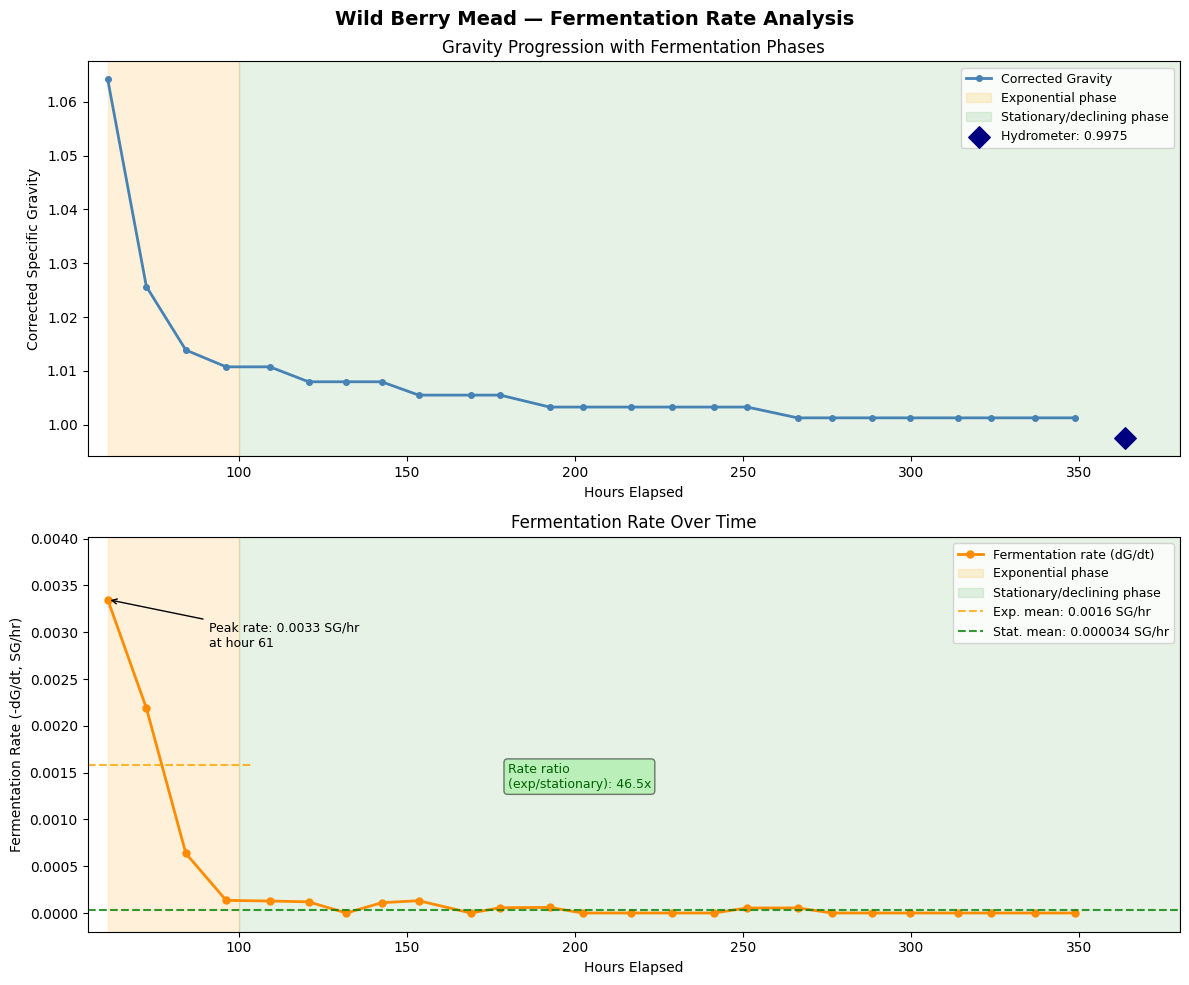

Plot saved as fermentation_rate.png

Key findings:
  Peak fermentation rate:          0.0033 SG/hr at hour 61
  Exponential phase mean rate:     0.0016 SG/hr
  Stationary phase mean rate:      0.000034 SG/hr
  Rate reduction (exp→stationary): 46.5x


In [9]:
# Cell 6 — Fermentation Rate Plot with Phase Labelling

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Wild Berry Mead — Fermentation Rate Analysis',
             fontsize=14, fontweight='bold')

# pull peak rate info, already calculated in previous block
peak_idx = df_rate_reliable['ferm_rate'].idxmax()
peak_hour = df_rate_reliable.loc[peak_idx, 'hours']
peak_rate = df_rate_reliable.loc[peak_idx, 'ferm_rate']

# use mean values already calculated
exp_mean = exp_mean_r
stat_mean = stat_mean_r

# Plot 1: Gravity with phase regions shaded
ax1.plot(df_rate_reliable['hours'], df_rate_reliable['gravity'],
         color='steelblue', linewidth=2, marker='o', markersize=4,
         label='Corrected Gravity')

# shade phases
ax1.axvspan(61, exp_end, alpha=0.15, color='orange', label='Exponential phase')
ax1.axvspan(exp_end, 380, alpha=0.1, color='green', label='Stationary/declining phase')

# hydrometer point as anchor
ax1.scatter(df_hydro['hours'], df_hydro['gravity'], color='navy',
            zorder=6, s=120, marker='D', label=f'Hydrometer: {hydrometer_corrected:.4f}')

ax1.set_xlabel('Hours Elapsed')
ax1.set_ylabel('Corrected Specific Gravity')
ax1.set_title('Gravity Progression with Fermentation Phases')
ax1.legend(fontsize=9)
ax1.set_xlim(55, 380)

# Plot 2: Fermentation rate vs time
ax2.plot(df_rate_reliable['hours'], df_rate_reliable['ferm_rate'],
         color='darkorange', linewidth=2, marker='o', markersize=5,
         label='Fermentation rate (dG/dt)')

# shade same phases on rate plot
ax2.axvspan(61, exp_end, alpha=0.15, color='orange', label='Exponential phase')
ax2.axvspan(exp_end, 380, alpha=0.1, color='green', label='Stationary/declining phase')

# annotate peak rate, arrow for peak rate point
ax2.annotate(f'Peak rate: {peak_rate:.4f} SG/hr\nat hour {peak_hour:.0f}',
             xy=(peak_hour, peak_rate),
             xytext=(peak_hour + 30, peak_rate * 0.85),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

# label rate ratio in stationary phase region in open space
# hardcoding 46.5x here since it was already calculated
ax2.annotate(f'Rate ratio\n(exp/stationary): {rate_ratio:.1f}x',
             xy=(180, stat_mean),
             xytext=(180, peak_rate * 0.4),
             fontsize=9, color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

# mean rate reference lines for each phase
ax2.axhline(y=exp_mean, xmin=0, xmax=0.15, color='orange',
            linestyle='--', linewidth=1.5, alpha=0.8,
            label=f'Exp. mean: {exp_mean:.4f} SG/hr')
ax2.axhline(y=stat_mean, color='green',
            linestyle='--', linewidth=1.5, alpha=0.8,
            label=f'Stat. mean: {stat_mean:.6f} SG/hr')

ax2.set_xlabel('Hours Elapsed')
ax2.set_ylabel('Fermentation Rate (-dG/dt, SG/hr)')
ax2.set_title('Fermentation Rate Over Time')
ax2.legend(fontsize=9)
ax2.set_xlim(55, 380)
ax2.set_ylim(-0.0002, peak_rate * 1.2)

plt.tight_layout()
plt.savefig('fermentation_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as fermentation_rate.png")
print(f"\nKey findings:")
print(f"  Peak fermentation rate:          {peak_rate:.4f} SG/hr at hour {peak_hour:.0f}")
print(f"  Exponential phase mean rate:     {exp_mean:.4f} SG/hr")
print(f"  Stationary phase mean rate:      {stat_mean:.6f} SG/hr")
print(f"  Rate reduction (exp→stationary): {rate_ratio:.1f}x")

In [10]:
# Cell 7 — ABV Prediction Tool
# using interpolation on actual data rather than logistic model
# tried using the logistic model first but the asymptote was too high so it couldnt predict ABVs above ~12.5%, interpolation works better

from scipy.interpolate import interp1d

# start with reliable refractometer data from hour 60+
df_interp = df[(~df['is_hydrometer']) & (df['hours'] >= 60)].copy()

# add hydrometer reading as final anchor point
# this is the most accurate gravity measurement so it anchors end of curve
hydro_hour = 363.5
hydro_abv = (OG_gravity - hydrometer_corrected) * 131.25

hydro_row = pd.DataFrame({
    'hours': [hydro_hour],
    'gravity': [hydrometer_corrected],
    'ABV': [hydro_abv]
})

# add hydrometer row onto end of dataframe
df_interp = pd.concat([df_interp[['hours', 'gravity', 'ABV']],
                        hydro_row]).reset_index(drop=True)

# sort by hours to ensure order
df_interp = df_interp.sort_values('hours').reset_index(drop=True)
df_interp = df_interp.reset_index(drop=True)  # reset again

# build interpolator (cubic) for gravity as function of hours
# cubic gives smoother curve than linear
gravity_interp = interp1d(df_interp['hours'], df_interp['gravity'],
                           kind='cubic', fill_value='extrapolate')

# build the reverse interpolator aka given a target gravity, what hour does it occur
# remove duplicate gravity values (function breaks without this)
# gravity sorted descending since it decreases over time
df_mono = df_interp.copy()
df_mono = df_mono.drop_duplicates(subset='gravity')
df_mono = df_mono.sort_values('gravity', ascending=False).reset_index(drop=True)

time_from_gravity = interp1d(df_mono['gravity'], df_mono['hours'],
                              kind='linear', fill_value='extrapolate')

# given target ABV, convert to target gravity and look up the time
def predict_time_to_abv(target_abv, og=OG_gravity):
    # rearrange to get target gravity
    target_gravity = og - (target_abv / 131.25)

    # check if target is actually possible
    if target_gravity < hydrometer_corrected:
        return None, target_gravity, "Exceeds yeast capacity (below hydrometer FG)"
    if target_gravity > df_interp['gravity'].iloc[0]:
        return None, target_gravity, "Already exceeded at start of reliable data"

    # look up the time from reverse interpolator
    t = float(time_from_gravity(target_gravity))
    return t, target_gravity, "Success"

print("=" * 65)
print("ABV PREDICTION TOOL — Data Interpolation Method")
print("=" * 65)
print(f"\nModel anchored to {len(df_interp)} data points + hydrometer validation")
print(f"Gravity range: {df_interp['gravity'].max():.4f} → {df_interp['gravity'].min():.4f}")

print(f"\n{'Target ABV':>12} {'Target SG':>11} {'Predicted Hours':>16} {'Predicted Days':>15}")
print("-" * 58)

abv_targets = [7, 9, 10, 11, 12, 12.5, 13, 13.5, 13.76]
results = []
for abv in abv_targets:
    t, g, status = predict_time_to_abv(abv)
    if t is not None:
        days = t / 24
        print(f"{abv:>11.2f}% {g:>11.4f} {t:>15.1f} hrs {days:>14.1f} days")
        results.append((abv, g, t))
    else:
        print(f"{abv:>11.2f}% {g:>11.4f} {'N/A':>15}   {status}")

print(f"\nActual final ABV (hydrometer): 13.76% at hour 363.5 (15.1 days)")

ABV PREDICTION TOOL — Data Interpolation Method

Model anchored to 26 data points + hydrometer validation
Gravity range: 1.0642 → 0.9975

  Target ABV   Target SG  Predicted Hours  Predicted Days
----------------------------------------------------------
       7.00%      1.0490            65.5 hrs            2.7 days
       9.00%      1.0337            70.1 hrs            2.9 days
      10.00%      1.0261            72.4 hrs            3.0 days
      11.00%      1.0185            79.6 hrs            3.3 days
      12.00%      1.0109            95.7 hrs            4.0 days
      12.50%      1.0071           132.7 hrs            5.5 days
      13.00%      1.0033           192.9 hrs            8.0 days
      13.50%      0.9994           312.7 hrs           13.0 days
      13.76%      0.9975           363.5 hrs           15.1 days

Actual final ABV (hydrometer): 13.76% at hour 363.5 (15.1 days)


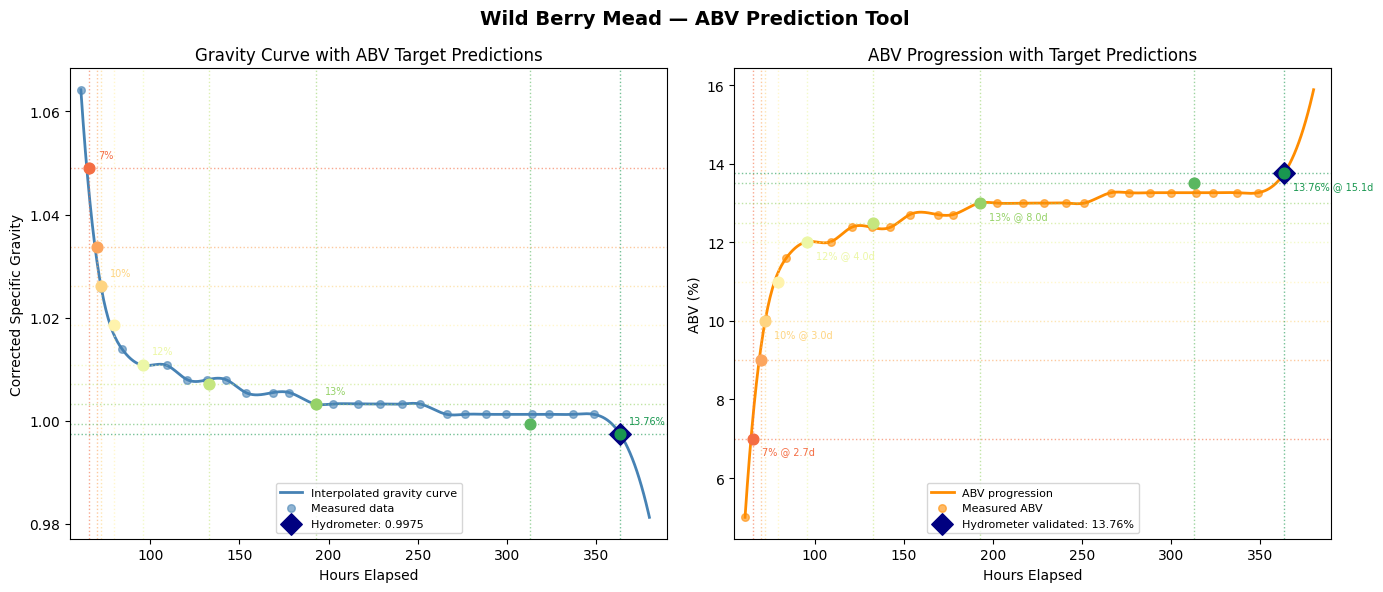

Plot saved as abv_prediction.png

Model validation:
  Predicted time to 13.76% ABV: 363.5 hours
  Actual time to 13.76% ABV:    363.5 hours
  Prediction error:             0.0 hours (0.0%)


In [11]:
# Cell 7 continued — ABV Prediction Plot

# generate smooth curves from interpolator
hours_smooth_interp = np.linspace(61, 380, 500)
gravity_smooth_interp = gravity_interp(hours_smooth_interp)

# convert smooth gravity curve to ABV
abv_smooth_interp = (OG_gravity - gravity_smooth_interp) * 131.25

# pull results into separate lists, easier than indexing
result_hours = []
result_abvs = []
result_gravities = []
for r in results:
    result_abvs.append(r[0])
    result_gravities.append(r[1])
    result_hours.append(r[2])

# color map for target ABV lines, red to green as ABV increases
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results)))

# pull hydrometer ABV for plot 2 label
hydro_abv_label = (OG_gravity - hydrometer_corrected) * 131.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wild Berry Mead — ABV Prediction Tool',
             fontsize=14, fontweight='bold')

# Plot 1: Gravity interpolation curve with targets
ax1.plot(hours_smooth_interp, gravity_smooth_interp, color='steelblue',
         linewidth=2, label='Interpolated gravity curve')
ax1.scatter(df_interp['hours'], df_interp['gravity'], color='steelblue',
            s=30, alpha=0.6, zorder=5, label='Measured data')
ax1.scatter(hydro_hour, hydrometer_corrected, color='navy', s=120,
            marker='D', zorder=6, label=f'Hydrometer: {hydrometer_corrected:.4f}')

# draw dotted crosshairs and a point for each target ABV
for i, (abv, g, t) in enumerate(results):
    ax1.axhline(y=g, color=colors[i], linestyle=':', alpha=0.6, linewidth=1)
    ax1.axvline(x=t, color=colors[i], linestyle=':', alpha=0.6, linewidth=1)
    ax1.scatter(t, g, color=colors[i], s=60, zorder=6)
    # label every other point so no overlap
    if i % 2 == 0:
        ax1.annotate(f'{abv}%', xy=(t, g), xytext=(t+5, g+0.002),
                     fontsize=7, color=colors[i])

ax1.set_xlabel('Hours Elapsed')
ax1.set_ylabel('Corrected Specific Gravity')
ax1.set_title('Gravity Curve with ABV Target Predictions')
ax1.legend(fontsize=8)
ax1.set_xlim(55, 390)

# Plot 2: ABV progression with targets
ax2.plot(hours_smooth_interp, abv_smooth_interp, color='darkorange',
         linewidth=2, label='ABV progression')
ax2.scatter(df_interp['hours'], df_interp['ABV'], color='darkorange',
            s=30, alpha=0.6, zorder=5, label='Measured ABV')
ax2.scatter(hydro_hour, hydro_abv_label, color='navy', s=120,
            marker='D', zorder=6, label=f'Hydrometer validated: {hydro_abv_label:.2f}%')

# same crosshairs on ABV plot
for i, (abv, g, t) in enumerate(results):
    ax2.axhline(y=abv, color=colors[i], linestyle=':', alpha=0.6, linewidth=1)
    ax2.axvline(x=t, color=colors[i], linestyle=':', alpha=0.6, linewidth=1)
    ax2.scatter(t, abv, color=colors[i], s=60, zorder=6)
    if i % 2 == 0:
        days_label = t / 24
        ax2.annotate(f'{abv}% @ {days_label:.1f}d', xy=(t, abv),
                     xytext=(t+5, abv - 0.4), fontsize=7, color=colors[i])

ax2.set_xlabel('Hours Elapsed')
ax2.set_ylabel('ABV (%)')
ax2.set_title('ABV Progression with Target Predictions')
ax2.legend(fontsize=8)
ax2.set_xlim(55, 390)

plt.tight_layout()
plt.savefig('abv_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as abv_prediction.png")

# test model against actual final measurement
predicted_final = results[-1][2]
actual_final = hydro_hour
prediction_error_hrs = abs(predicted_final - actual_final)
prediction_error_pct = (prediction_error_hrs / actual_final) * 100

print(f"\nModel validation:")
print(f"  Predicted time to 13.76% ABV: {predicted_final:.1f} hours")
print(f"  Actual time to 13.76% ABV:    {actual_final} hours")
print(f"  Prediction error:             {prediction_error_hrs:.1f} hours ({prediction_error_pct:.1f}%)")